In [1]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import sys
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as patches
import matplotlib.animation as animation


In [2]:
ds_idealized_100d= xr.open_dataset('../snap_idealized_100d.cdf')
ds_hourly = xr.open_dataset('../snap_hourly.cdf')

In [3]:
t_levels = ds_hourly['u'].shape[0]
print(f"Number of time levels: {t_levels}")


Number of time levels: 240


In [24]:
ds_hourly['u'][:240,0,:,:].shape

(240, 252, 504)

In [4]:
def create_animation_for_dataset(dataset, dataset_name, save_animation=True, z_level=0):
    """Create animation for a single dataset"""
    
    variables = ['u', 'v', 'w', 'p']
    
    # Get time levels from the dataset
    t_levels = None
    for var in variables:
        if var in dataset:
            t_levels = dataset[var].shape[0]
            break
    
    if t_levels is None:
        print(f"Error: No valid variables found in dataset {dataset_name}")
        return None, None
    
    # Compute color limits per variable across all levels and times for this dataset
    color_limits = {}
    for var in variables:
        if var in dataset:
            data_all = dataset[var][:t_levels, z_level, :, :]  # shape (t, y, x)
            color_limits[var] = (np.nanmin(data_all), np.nanmax(data_all))
        else:
            print(f"Warning: Variable {var} not found in dataset {dataset_name}")
            color_limits[var] = (0, 1)  # fallback
    
    # Create figure and subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axes = axs.ravel()
    images = []
    
    # Initialize plots
    for ax, var in zip(axes, variables):
        if var in dataset:
            data = dataset[var][0, z_level, :, :]
            vmin, vmax = color_limits[var]
            
            # Choose appropriate colormap based on variable
            if var in ['u', 'v']:  # velocity components
                cmap = 'RdBu_r'
            elif var == 'w':  # vertical velocity
                cmap = 'seismic'
            else:  # pressure or other
                cmap = 'viridis'
                
            im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, 
                          aspect='auto', origin='lower')
            ax.set_title(f'{var} ({dataset_name})', fontsize=12, fontweight='bold')
            ax.set_xlabel('x (grid points)')
            ax.set_ylabel('y (grid points)')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=8)
            
        else:
            # Handle missing variable
            im = ax.imshow(np.zeros((10, 10)), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{var} (NOT AVAILABLE)', fontsize=12, color='red')
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=20, color='red')
            
        images.append(im)
    
    fig.suptitle(f'Dataset: {dataset_name} - Time step: 0', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    
    def update(frame):
        """Update function for animation"""
        updated_artists = []
        for i, var in enumerate(variables):
            if var in dataset:
                data = dataset[var][frame, z_level, :, :]
                images[i].set_data(data)
                updated_artists.append(images[i])
        
        fig.suptitle(f'Dataset: {dataset_name} - Time step: {frame}', 
                    fontsize=16, fontweight='bold')
        return updated_artists
    
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=t_levels, 
                                 interval=300, blit=False, repeat=True)
    
    if save_animation:
        # Create output directory
        output_dir = 'fig_idealized'
        os.makedirs(output_dir, exist_ok=True)
        """
        # Save as GIF (optional - requires pillow or imagemagick)
        try:
            gif_filename = os.path.join(output_dir, f'animation_{dataset_name}.gif')
            ani.save(gif_filename, writer='pillow', fps=3)
            print(f"Saved GIF animation: {gif_filename}")
        except Exception as e:
            print(f"Could not save GIF for {dataset_name}: {e}")
        """
        # Save as MP4 (optional - requires ffmpeg)
        try:
            mp4_filename = os.path.join(output_dir, f'animation_{dataset_name}_z={z_level}.mp4')
            ani.save(mp4_filename, writer='ffmpeg', fps=3, bitrate=1800)
            print(f"Saved MP4 animation: {mp4_filename}")
        except Exception as e:
            print(f"Could not save MP4 for {dataset_name}: {e}")
    
    return ani, fig

In [18]:
ds_hourly

<xarray.Dataset> Size: 49GB
Dimensions:  (Time: 240, z: 40, y: 252, x: 504)
Coordinates:
  * x        (x) float64 4kB 0.0 1.984e+03 3.968e+03 ... 9.96e+05 9.98e+05
  * y        (y) float64 2kB 0.0 1.984e+03 3.968e+03 ... 4.96e+05 4.98e+05
  * z        (z) float64 320B 0.0 50.0 100.0 150.0 ... 1.85e+03 1.9e+03 1.95e+03
  * Time     (Time) float64 2kB 0.0 3.6e+03 7.2e+03 ... 8.568e+05 8.604e+05
Data variables:
    u        (Time, z, y, x) float64 10GB ...
    v        (Time, z, y, x) float64 10GB ...
    w        (Time, z, y, x) float64 10GB ...
    b        (Time, z, y, x) float64 10GB ...
    p        (Time, z, y, x) float64 10GB ...
Attributes:
    dx:       1984.126984126984
    dy:       1984.126984126984
    dz:       50.0
    N0:       0.0029999999242136255
    f0:       9.999999747378752e-05
    Ro:       1.0
    dsqr:     1.0

Saved MP4 animation: fig_idealized/animation_idealized_100d_z=20.mp4


(<matplotlib.animation.FuncAnimation at 0x7fff91b0c0e0>,
 <Figure size 1400x1000 with 8 Axes>)

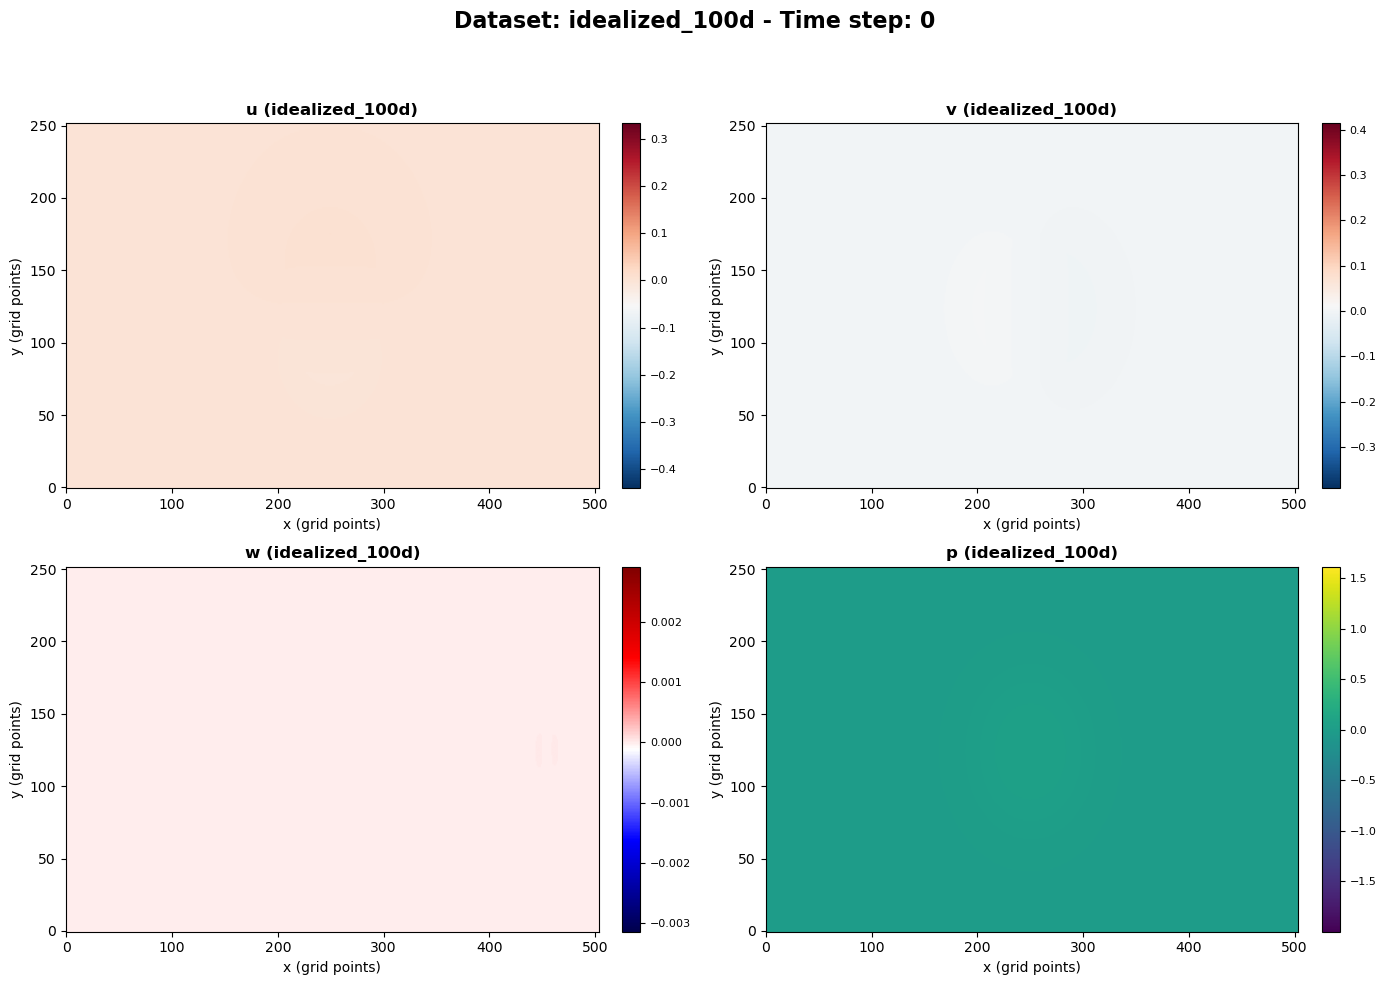

In [16]:
create_animation_for_dataset(ds, 'idealized_100d', z_level=20)

Saved MP4 animation: fig_idealized/animation_hourly_output_10d_z=0.mp4


(<matplotlib.animation.FuncAnimation at 0x7fff915bb620>,
 <Figure size 1400x1000 with 8 Axes>)

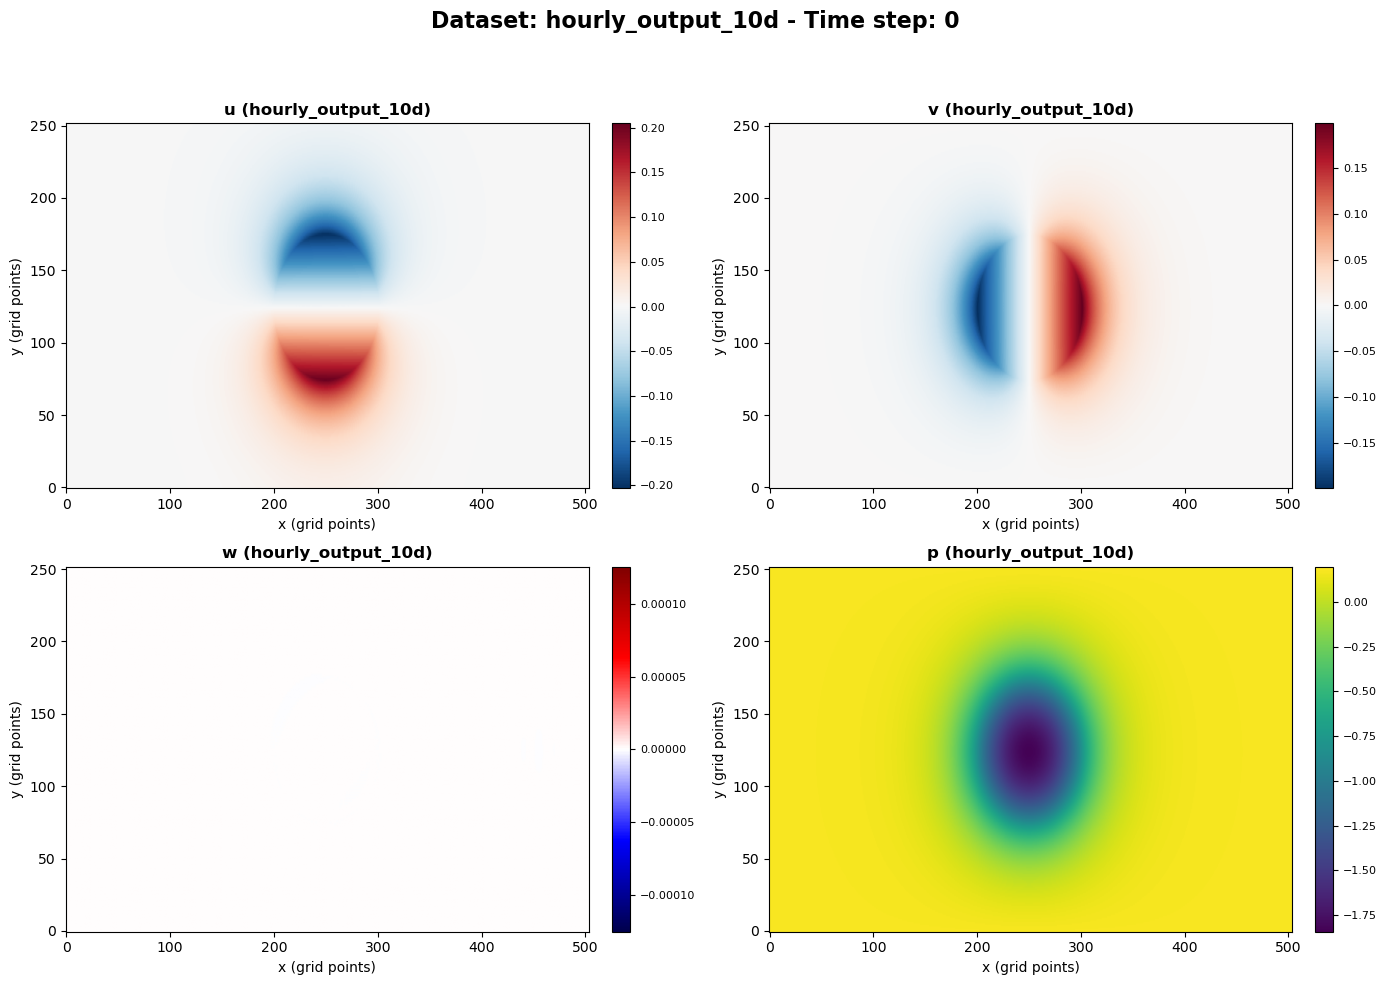

In [26]:
create_animation_for_dataset(ds_hourly, 'hourly_output_10d', z_level=0)

In [5]:
# Band pass for internal tides
from scipy.signal import butter, lfilter

# cut off 
nyquist_freq = 1.0 / 2.0  # Nyquist frequency
#low_cutoff_freq = 1.0 / (15 )  
#high_cutoff_freq = 1.0 / (9 )  
low_cutoff_freq = 1.0 / (15 )  ## here the unit is hour, that means you have hourly data
high_cutoff_freq = 1.0 / (10 ) 
# low_cutoff_freq = 1.0 / (9 )  
# high_cutoff_freq = 1.0 / (3 )
order = 2  # Filter order 


def butter_bandpass(lowcut, highcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    high = highcut / nyquist_freq
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

b2, a2 = butter_bandpass(low_cutoff_freq, high_cutoff_freq, nyquist_freq, order=order)



In [6]:
u = ds_hourly.u[:,0,:,:]
v = ds_hourly.v[:,0,:,:]
w = ds_hourly.w[:,0,:,:]
p = ds_hourly.p[:,0,:,:]

In [7]:


bpu = lfilter(b2, a2, u, axis=0)


In [9]:
bpv = lfilter(b2, a2, v, axis=0)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Assuming bpu is your data array with shape (N, height, width)
# where N is the number of frames you want to animate through

def animate_array(data, interval=100, save_as=None, title_prefix="Frame"):
    """
    Create an animation cycling through all elements along the first dimension of any 3D array.
    
    Parameters:
    data : numpy.ndarray
        3D array with shape (N, height, width) - works with bpu, bpv, bpp, or any other array
    interval : int
        Delay between frames in milliseconds (default: 100)
    save_as : str, optional
        Filename to save animation (e.g., 'animation.gif' or 'animation.mp4')
    title_prefix : str
        Prefix for the frame title (default: "Frame")
    """
    
    # Input validation
    if len(data.shape) != 3:
        raise ValueError(f"Data must be 3D array, got shape {data.shape}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Get global min/max for consistent color scaling across all frames
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    print(f"Data shape: {data.shape}")
    print(f"Data range: {vmin:.3f} to {vmax:.3f}")
    print(f"Animating {data.shape[0]} frames")
    
    # Initialize the plot with the first frame
    im = ax.imshow(data[0, :, :], cmap='RdBu_r', 
                   aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    
    # Set up the title to show current frame
    title = ax.set_title(f'{title_prefix} 0 / {data.shape[0]-1}')
    
    def animate(frame):
        """Animation function called for each frame"""
        im.set_data(data[frame, :, :])  # Use set_data instead of set_array
        title.set_text(f'{title_prefix} {frame} / {data.shape[0]-1}')
        return [im, title]
    
    # Create animation - disable blitting for better compatibility
    anim = animation.FuncAnimation(fig, animate, frames=data.shape[0],
                                 interval=interval, blit=False, repeat=True)
    
    # Save animation if filename provided
    if save_as:
        print(f"Saving animation as {save_as}...")
        if save_as.endswith('.gif'):
            anim.save(save_as, writer='pillow', fps=1000//interval)
        elif save_as.endswith('.mp4'):
            # Use matplotlib's default writer or specify ffmpeg
            try:
                anim.save(save_as, writer='ffmpeg', fps=1000//interval, bitrate=1800)
            except:
                # Fallback to default writer
                anim.save(save_as, fps=1000//interval, bitrate=1800)
        else:
            print("Unsupported format. Use .gif or .mp4")
        print("Animation saved!")
    
    plt.show()
    return anim




Data shape: (240, 252, 504)
Data range: -0.035 to 0.035
Animating 240 frames
Saving animation as animation_bpv.mp4...
Animation saved!


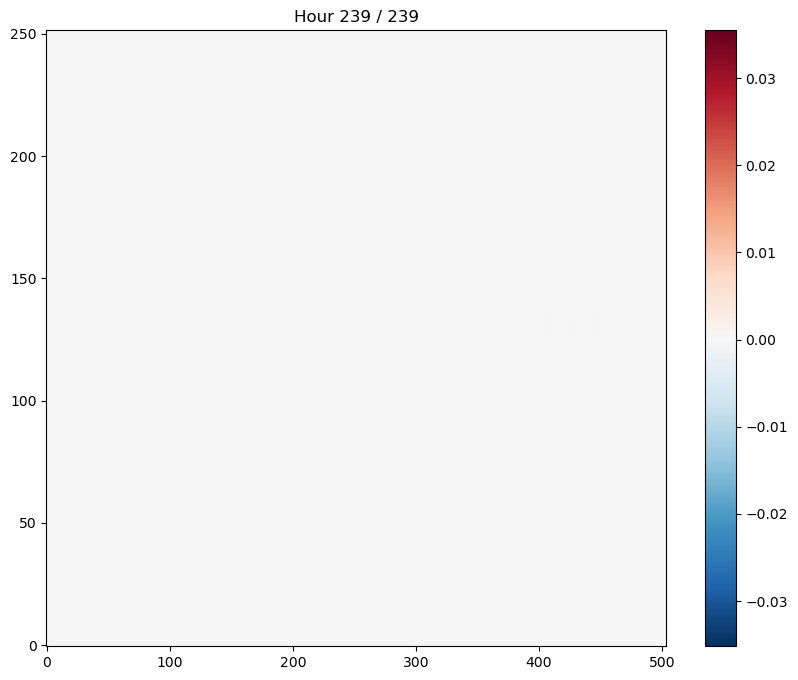

In [ ]:
ani = animate_array(bpu, interval=150, save_as='animation_bpu.mp4', title_prefix="Hour")
ani = animate_array(bpv, interval=150, save_as='animation_bpv.mp4', title_prefix="Hour")

In [7]:



nyquist_freq = 1.0 / 2.0  # Nyquist frequency (half of the sampling frequency)
low_cutoff_freq = 1.0 / (62/24)  # High-pass cutoff frequency 
order = 2  # Filter order 

def butter_lowpass(lowcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    b, a = butter(order, low, btype='low', analog=False)
    return b, a

# low-pass filter
b2, a2 = butter_lowpass(low_cutoff_freq, nyquist_freq, order=order)



In [9]:
# Applying the low-pass filter
lpu4= lfilter(b2, a2, u,axis=0)
lpv4 = lfilter(b2, a2, v,axis=0)

Data shape: (240, 252, 504)
Data range: -0.238 to 0.239
Animating 240 frames
Saving animation as animation_lpu.mp4...
Animation saved!


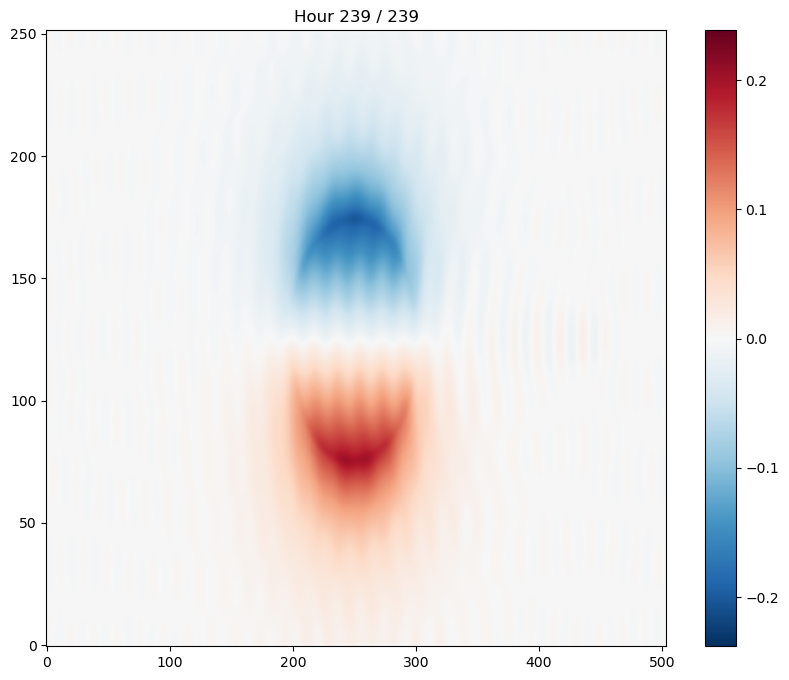

Data shape: (240, 252, 504)
Data range: -0.236 to 0.234
Animating 240 frames
Saving animation as animation_lpv.mp4...
Animation saved!


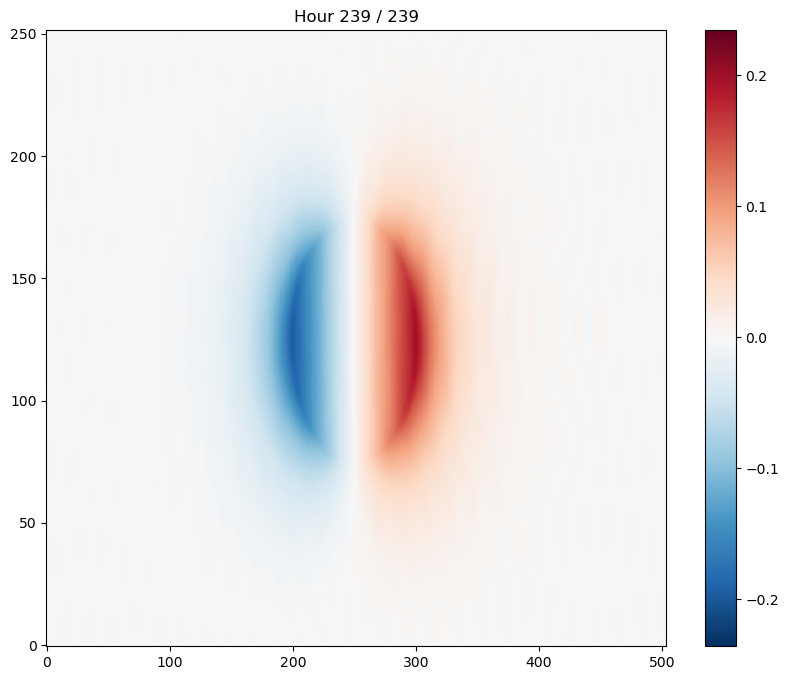

In [12]:
ani = animate_array(lpu4, interval=150, save_as='animation_lpu.mp4', title_prefix="Hour")
ani = animate_array(lpv4, interval=150, save_as='animation_lpv.mp4', title_prefix="Hour")

In [8]:
lpw4 = lfilter(b2, a2, w,axis=0)


Data shape: (240, 252, 504)
Data range: -0.000 to 0.000
Animating 240 frames
Saving animation as animation_lpw.mp4...
Animation saved!


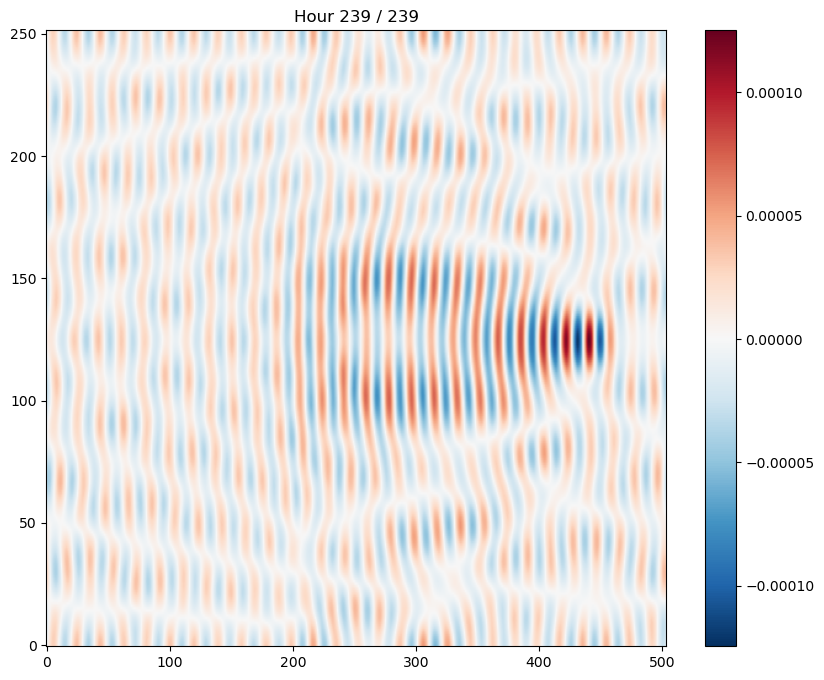

In [9]:
ani = animate_array(lpw4, interval=150, save_as='animation_lpw.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -2.163 to 0.207
Animating 240 frames
Saving animation as animation_lpb.mp4...
Animation saved!


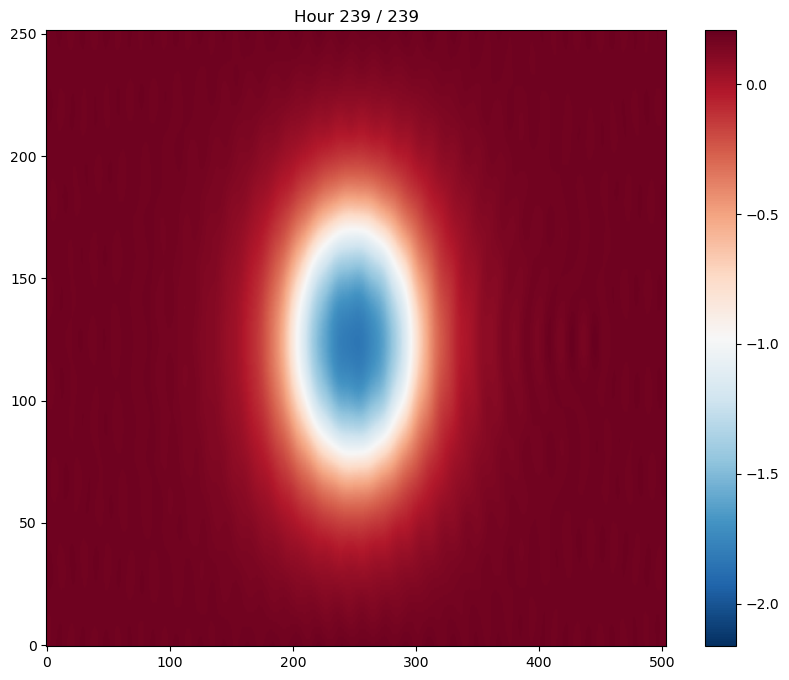

In [10]:
lpb4 = lfilter(b2, a2, p,axis=0)
ani = animate_array(lpb4, interval=150, save_as='animation_lpb.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -0.307 to 0.325
Animating 240 frames
Saving animation as animation_bpp.mp4...
Animation saved!


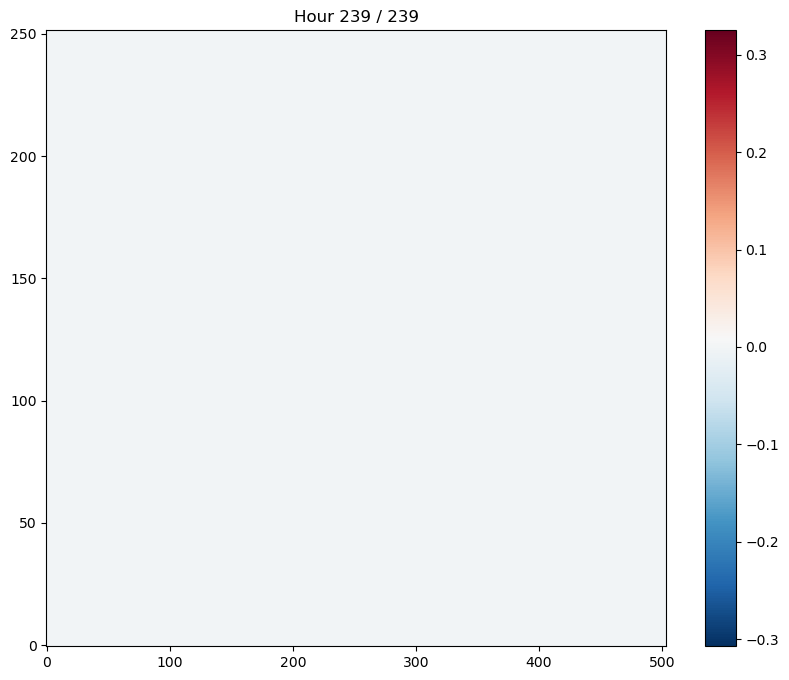

In [8]:
bpp = lfilter(b2, a2, p, axis=0)
ani = animate_array(bpp, interval=150, save_as='animation_bpp.mp4', title_prefix="Hour")

Data shape: (240, 252, 504)
Data range: -0.000 to 0.000
Animating 240 frames
Saving animation as animation_bpw.mp4...
Animation saved!


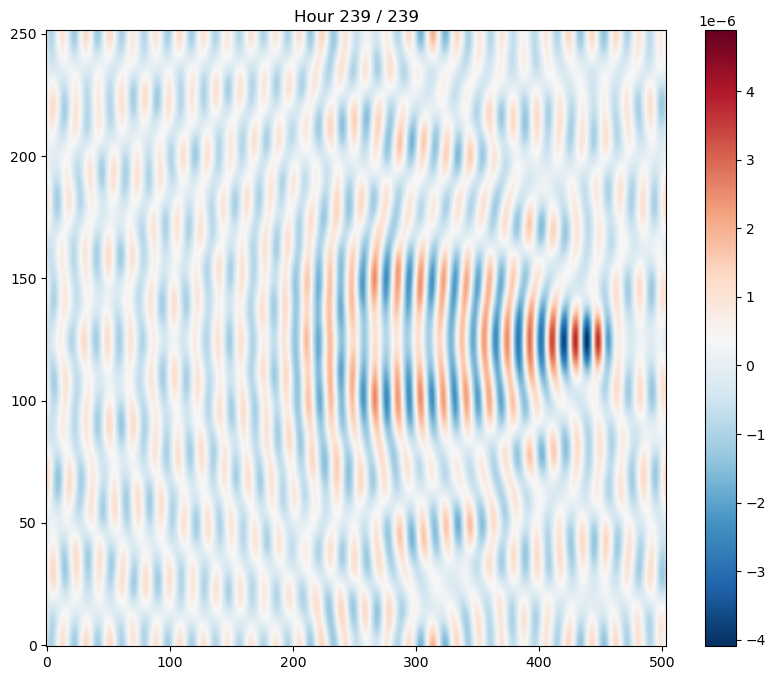

In [9]:
bpw = lfilter(b2, a2, w, axis=0)
ani = animate_array(bpw, interval=150, save_as='animation_bpw.mp4', title_prefix="Hour")